In [1]:
import sys
sys.path.remove('/user/home/ef17148/.local/lib/python3.12/site-packages')


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr

import sys
sys.path.insert(0, "..")

from model.data.load_data import LoadSquareSatelliteData

In [4]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [18]:
from vis_plotting.fp_plotting import *
from vis_plotting.general_plotting import *
from vis_plotting.topog_plotting import *
from vis_plotting.met_plotting import *

# Data loading: 
load the footprints, meteorology and topography and crop to a square domain of size SxS centered around the measurement location.

This allows for plotting that is specific to the footprint locations.

In [6]:
data = LoadSquareSatelliteData(2016, freq=10, size=50, region="BRAZIL", load_everything=True, verbose=True, load_fps_as="both")

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2016*.nc
reduced the number of datapoints by frequency 10
Loading 2168 footprints
----- Cutting footprints to square of size 50
careful! We had to pad the footprints along the longitude dimension to extract size 50 (0 and 2 idxs on either side) Padding with nan
35 footprints were at least partially filled with nans because they were cutting outside of the footprint file domain (this is 1.61% of samples)
Padding was needed for the following number of footprints along each direction: {'N': 0, 'S': 0, 'E': 35, 'W': 0}

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/SOUTHAMERICA/SOUTHAMERICA_Met_2016*.nc
----- Cutting met


/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockwise(
/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages/dask/array/core.py:4839: PerformanceWarning: Increasing number of chunks by factor of 12
  result = blockw

calculated wind angle and/or speed from x_wind and y_wind

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
----- Cutting topog
---- All done!


In [16]:
# the cropped footprints are stored as an xarray with euclidean coordinates, so that lat and lon have range (0,S), and the measurement coordinate is at (S//2, S//2)
# the time axis is the same as the original footprint dataset, stored under data.fp_data_full
data.fp_xr

<xarray.Dataset>
Dimensions:      (lat: 50, lon: 50, time: 2168)
Coordinates:
  * time         (time) datetime64[ns] 2016-01-01T14:59:12.500000 ... 2016-12...
  * lon          (lon) int64 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
  * lat          (lat) int64 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49
Data variables:
    fp           (lat, lon, time) float32 dask.array<chunksize=(50, 48, 1), meta=np.ndarray>
    lat_coords   (time, lat) float32 -15.35 -15.12 -14.88 ... 2.901 3.135 3.369
    lon_coords   (time, lon) float64 -45.22 -44.87 -44.51 ... -62.82 -62.47
    release_lat  (time) float32 -9.448 -17.15 -25.8 ... 4.757 -30.92 -2.27
    release_lon  (time) float32 -36.36 -57.54 -62.11 ... -47.67 -58.11 -70.83
Attributes:
    max_level:  17
    author:     rt17603
    created:    2019-05-29 20:05:49.874413

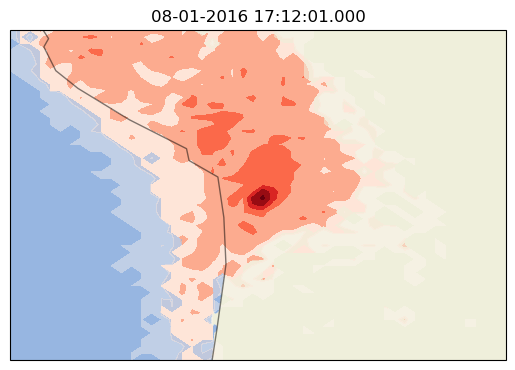

In [7]:
# use this function to plot the footprint of a single sample
data.plot_cropped_footprint(idx=25)

# Plotting meteorology

In [ ]:
# the cropped meteorology is stored as an xarray with the same lat-lon coordinates as fp_xr in data.met
data.met

In [ ]:
# the footprint location is situated at the center of the domain
measurement_idx = data.size//2

25

<WindroseAxes: title={'center': 'Per-footprint Wind Rose \n Level 1'}>

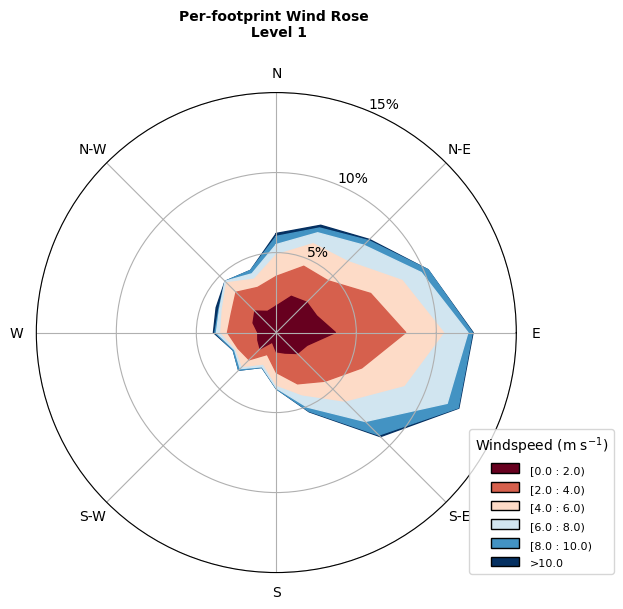

In [19]:
plot_single_windrose(data.met.sel(lat=measurement_idx, lon=measurement_idx, levels=1),  limit=15, legend=True, title=f"Per-footprint Wind Rose \n Level 1")

# Plotting topography

In [ ]:
# the cropped topography and landuse is stored in a dataset with the same lat-lon coordinates as fp_xr
# the data.topog.landcover variable shows the highest landcover class at each grid cell, and the data.topog.disaggregated_landcover variable shows the fraction of each landcover class at each grid cell
data.topog

<xarray.Dataset>
Dimensions:                  (time: 2168, lat: 50, lon: 50, landcover_level: 10)
Coordinates:
  * time                     (time) datetime64[ns] 2016-01-01T14:59:12.500000...
  * lat                      (lat) int64 0 1 2 3 4 5 6 ... 43 44 45 46 47 48 49
  * lon                      (lon) int64 0 1 2 3 4 5 6 ... 43 44 45 46 47 48 49
  * landcover_level          (landcover_level) int64 0 1 2 3 4 5 6 7 8 9
Data variables:
    topog                    (time, lat, lon) float32 635.9 628.9 ... 282.2
    landcover                (time, lat, lon) float32 4.0 4.0 1.0 ... 1.0 1.0
    disaggregated_landcover  (time, lat, lon, landcover_level) float64 0.0 .....

In [ ]:
# histogram here of the heights at the measurement locations?